# DLP False Positive 필터 — 지도학습 알고리즘 비교

> **과제**: 머신러닝 지도학습 알고리즘을 적용한 자기만의 예제  
> **문제**: 규칙 기반 DLP 파이프라인의 Regex 탐지 결과에서 **오탐(False Positive)을 분류**하는 이진 분류기  
> **데이터**: `tests/pii_findings_ml_dataset.csv` (622건, 17개 feature)

## 알고리즘 후보 7개

| # | 알고리즘 | 분류 방식 | 특징 |
|---|---|---|---|
| 1 | **Logistic Regression** | 선형 확률 모델 | 빠름, 해석 용이, 베이스라인 |
| 2 | **Random Forest** | 배깅 앙상블 | 비선형, feature importance 제공 |
| 3 | **XGBoost** | 부스팅 앙상블 | tabular 데이터 SOTA, 빠른 추론 |
| 4 | SVM (RBF kernel) | 최대 마진 | 비선형 경계, 커널 트릭 |
| 5 | K-Nearest Neighbors | 거리 기반 | 단순 직관적, 비모수적 |
| 6 | Naive Bayes | 확률 기반 | 매우 빠름, 독립 가정 |
| 7 | Decision Tree | 트리 분기 | 해석 가능, 과적합 주의 |

**최종 선택 3개**: Logistic Regression / Random Forest / XGBoost

In [1]:
# 0. 라이브러리 임포트
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, auc,
    f1_score, precision_score, recall_score, roc_auc_score,
    fbeta_score, make_scorer
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
import joblib

matplotlib.rcParams['axes.unicode_minus'] = False
try:
    matplotlib.rcParams['font.family'] = 'NanumGothic'
except Exception:
    matplotlib.rcParams['font.family'] = 'DejaVu Sans'

DATA_PATH = Path('../tests/pii_findings_ml_dataset.csv')
print(f'sklearn {__import__("sklearn").__version__}  |  xgboost {xgb.__version__}')

sklearn 1.8.0  |  xgboost 3.2.0


---
## 1. 데이터 로드 및 탐색 (EDA)

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'형태: {df.shape}')
print(f'컬럼: {list(df.columns)}')
df.head()

형태: (622, 19)
컬럼: ['_case_id', 'rule_name', 'severity_level', 'match_length', 'match_digit_ratio', 'match_alpha_ratio', 'match_special_ratio', 'match_entropy', 'ctx_before_len', 'ctx_after_len', 'pii_keyword_hits', 'code_signal_strong', 'code_signal_weak', 'is_in_quotes', 'is_assignment_rhs', 'is_in_url', 'text_total_length', 'current_confidence', 'label']


,_case_id,rule_name,severity_level,match_length,match_digit_ratio,match_alpha_ratio,match_special_ratio,match_entropy,ctx_before_len,ctx_after_len,pii_keyword_hits,code_signal_strong,code_signal_weak,is_in_quotes,is_assignment_rhs,is_in_url,text_total_length,current_confidence,label
0,TP-RRN-001,kr_rrn,4,14,0.9286,0.0,0.0714,2.6995,15,5,3,0,0,0,0,0,34,1.0,1
1,TP-RRN-002,kr_rrn,4,14,0.9286,0.0,0.0714,2.8424,15,0,3,0,0,0,1,0,29,1.0,1
2,TP-RRN-003,kr_rrn,4,14,0.9286,0.0,0.0714,2.2170,36,0,3,0,0,0,1,0,50,1.0,1
3,TP-RRN-004,kr_rrn,4,14,0.9286,0.0,0.0714,2.8424,15,5,3,0,0,0,0,0,34,1.0,1
4,TP-RRN-005,kr_rrn,4,14,0.9286,0.0,0.0714,2.8963,15,0,3,0,0,0,1,0,29,1.0,1


In [3]:
print('=== 레이블 분포 ===')
print(df['label'].value_counts().rename({1: 'TP(진짜PII)', 0: 'FP(오탐)'}))
print('\n=== 결측값 ===')
print(df.isnull().sum().sum(), '개')
df.describe()

=== 레이블 분포 ===
label
TP(진짜PII)    311
FP(오탐)       311
Name: count, dtype: int64

=== 결측값 ===
0 개


,severity_level,match_length,match_digit_ratio,match_alpha_ratio,match_special_ratio,match_entropy,ctx_before_len,ctx_after_len,pii_keyword_hits,code_signal_strong,code_signal_weak,is_in_quotes,is_assignment_rhs,is_in_url,text_total_length,current_confidence,label
count,622.000000,622.000000,622.000000,622.000000,622.000000,622.000000,622.000000,622.000000,622.000000,622.000000,622.000000,622.000000,622.000000,622.0,622.000000,622.000000,622.000000
mean,3.151125,38.471061,0.445463,0.462032,0.083485,3.882177,19.663987,4.580386,1.612540,0.077170,0.418006,0.284566,0.302251,0.0,62.805466,0.777910,0.500000
std,0.937494,38.504511,0.383036,0.390821,0.072633,0.981175,9.616878,7.930199,1.354674,0.267076,0.764888,0.451571,0.459603,0.0,41.637139,0.309046,0.500402
min,1.000000,9.000000,0.000000,0.000000,0.000000,1.823100,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,9.000000,0.180000,0.000000
25%,3.000000,14.000000,0.060600,0.000000,0.000000,3.169900,14.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,34.000000,0.600000,0.000000
50%,3.000000,20.000000,0.250000,0.670450,0.071400,3.616900,18.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,50.000000,1.000000,0.500000
75%,4.000000,42.000000,0.842100,0.824100,0.153800,4.910000,26.000000,5.000000,3.000000,0.000000,0.000000,1.000000,1.000000,0.0,70.750000,1.000000,1.000000
max,4.000000,146.000000,1.000000,0.976200,0.250000,5.518700,57.000000,30.000000,5.000000,1.000000,2.000000,1.000000,1.000000,0.0,203.000000,1.000000,1.000000


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


...

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


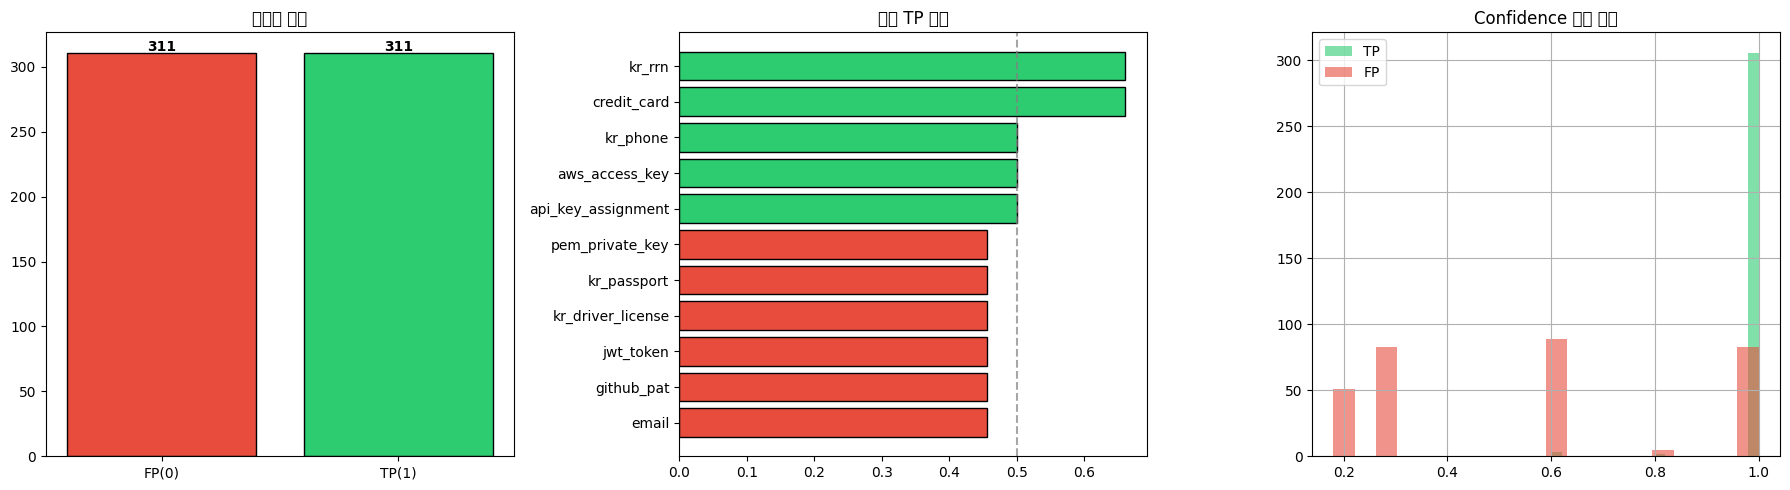

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 레이블 분포
lc = df['label'].value_counts()
axes[0].bar(['FP(0)', 'TP(1)'], [lc[0], lc[1]], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('레이블 분포')
for i, v in enumerate([lc[0], lc[1]]):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# 룰별 TP 비율
rl = df.groupby('rule_name')['label'].mean().sort_values()
colors = ['#e74c3c' if v < 0.5 else '#2ecc71' for v in rl.values]
axes[1].barh(rl.index, rl.values, color=colors, edgecolor='black')
axes[1].axvline(0.5, color='gray', linestyle='--', alpha=0.7)
axes[1].set_title('룰별 TP 비율')

# Confidence 분포 비교
df[df['label']==1]['current_confidence'].hist(alpha=0.6, bins=20, ax=axes[2], color='#2ecc71', label='TP')
df[df['label']==0]['current_confidence'].hist(alpha=0.6, bins=20, ax=axes[2], color='#e74c3c', label='FP')
axes[2].set_title('Confidence 분포 비교')
axes[2].legend()

plt.tight_layout()
plt.savefig('../docs/eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


...

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


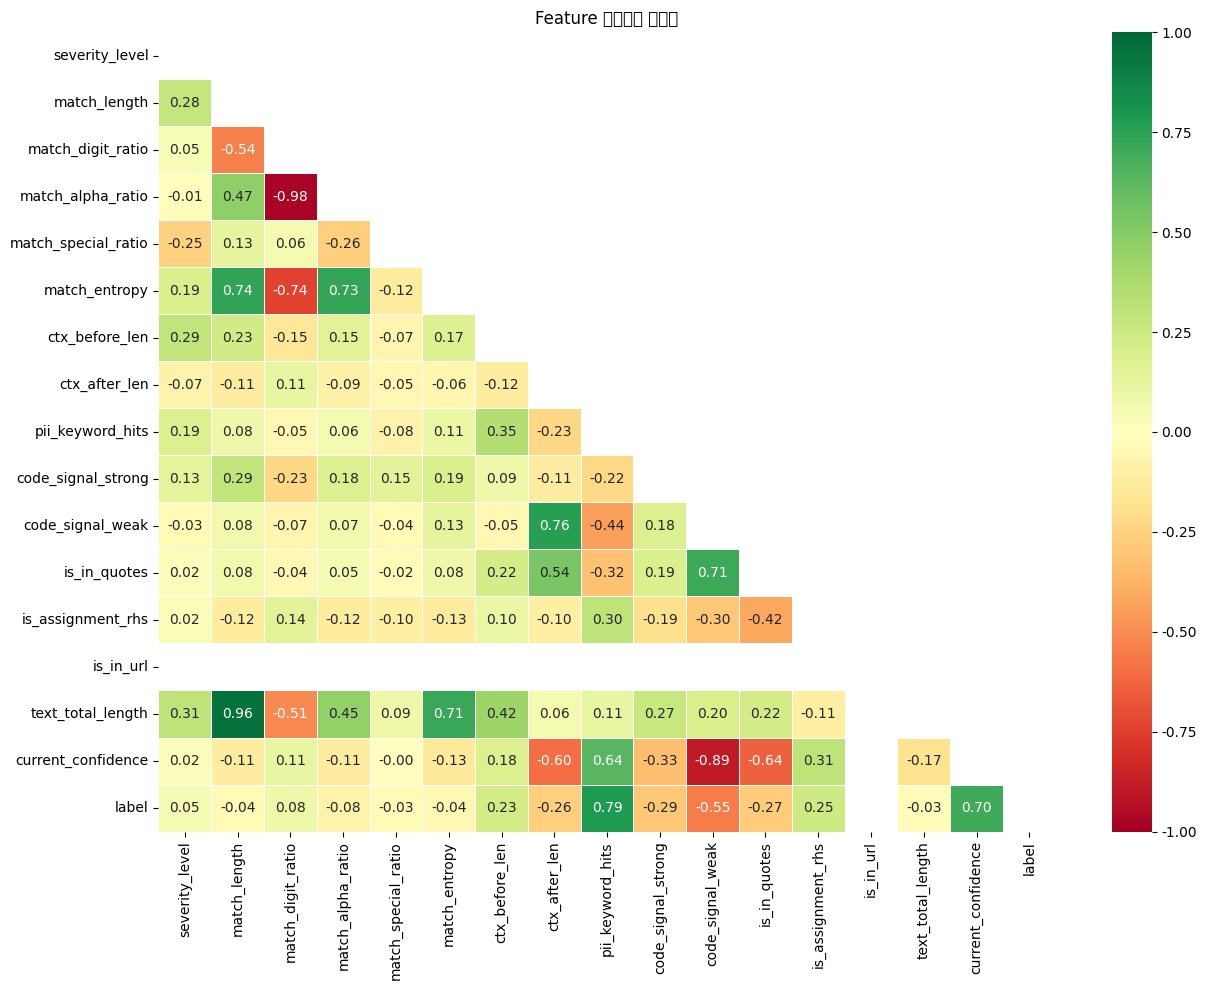

In [5]:
numeric_cols = [
    'severity_level', 'match_length', 'match_digit_ratio', 'match_alpha_ratio',
    'match_special_ratio', 'match_entropy', 'ctx_before_len', 'ctx_after_len',
    'pii_keyword_hits', 'code_signal_strong', 'code_signal_weak',
    'is_in_quotes', 'is_assignment_rhs', 'is_in_url',
    'text_total_length', 'current_confidence', 'label'
]

plt.figure(figsize=(13, 10))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature 상관관계 히트맵')
plt.tight_layout()
plt.savefig('../docs/eda_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


...

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


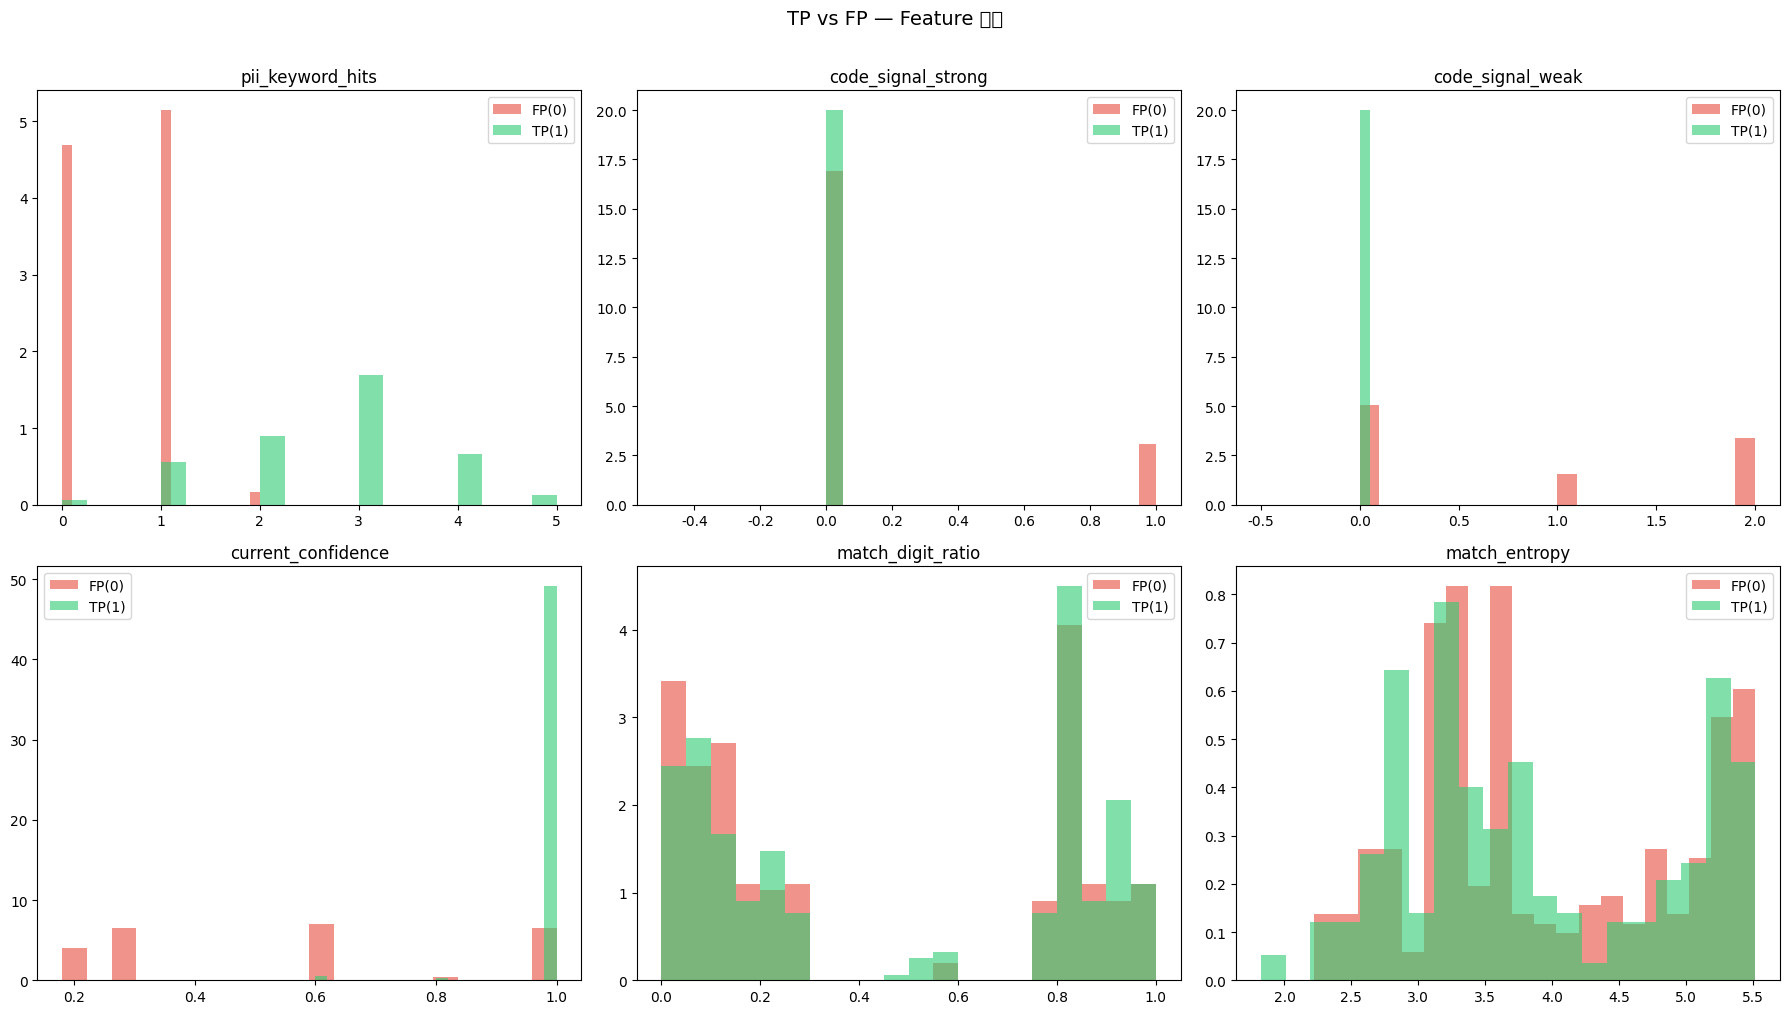

In [6]:
features_to_plot = ['pii_keyword_hits', 'code_signal_strong', 'code_signal_weak',
                    'current_confidence', 'match_digit_ratio', 'match_entropy']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    axes[i].hist(df[df['label']==0][feat], bins=20, alpha=0.6, color='#e74c3c', label='FP(0)', density=True)
    axes[i].hist(df[df['label']==1][feat], bins=20, alpha=0.6, color='#2ecc71', label='TP(1)', density=True)
    axes[i].set_title(feat)
    axes[i].legend()

plt.suptitle('TP vs FP — Feature 분포', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../docs/eda_feature_dist.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 2. 전처리 및 데이터 분할

In [7]:
drop_cols = ['_case_id'] if '_case_id' in df.columns else []
X = df.drop(columns=drop_cols + ['label'])
y = df['label']

cat_cols = ['rule_name']
num_cols = [c for c in X.columns if c not in cat_cols]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
])

# Train 70% / Val 15% / Test 15% (stratified)
X_tv, X_test, y_tv, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=0.176, stratify=y_tv, random_state=42)

print(f'Train  : {len(X_train):3d}건  TP={y_train.sum()}')
print(f'Val    : {len(X_val):3d}건  TP={y_val.sum()}')
print(f'Test   : {len(X_test):3d}건  TP={y_test.sum()}')

Train  : 435건  TP=218
Val    :  93건  TP=46
Test   :  94건  TP=47


---
## 3. 알고리즘 후보 7개 — 5-Fold CV 스크리닝

In [8]:
candidates = {
    '① Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=42),
    '② Random Forest':       RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    '③ XGBoost':             xgb.XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                                                eval_metric='logloss', random_state=42, verbosity=0),
    '④ SVM (RBF)':           SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced', probability=True, random_state=42),
    '⑤ KNN':                 KNeighborsClassifier(n_neighbors=7, weights='distance', n_jobs=-1),
    '⑥ Naive Bayes':         GaussianNB(),
    '⑦ Decision Tree':       DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42),
}

pipelines = {
    name: Pipeline([('prep', preprocessor), ('clf', model)])
    for name, model in candidates.items()
}

f2_scorer = make_scorer(fbeta_score, beta=2, pos_label=1)
scoring = {'F2': f2_scorer, 'Recall': 'recall', 'Precision': 'precision', 'ROC_AUC': 'roc_auc'}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}
for name, pipe in pipelines.items():
    scores = cross_validate(pipe, X_tv, y_tv, cv=cv, scoring=scoring, n_jobs=1)
    cv_results[name] = {
        'F2':        round(scores['test_F2'].mean(), 4),
        'F2_std':    round(scores['test_F2'].std(), 4),
        'Recall':    round(scores['test_Recall'].mean(), 4),
        'Precision': round(scores['test_Precision'].mean(), 4),
        'ROC_AUC':   round(scores['test_ROC_AUC'].mean(), 4),
    }
    print(f'{name:30s}  F2={cv_results[name]["F2"]:.4f}  Recall={cv_results[name]["Recall"]:.4f}  AUC={cv_results[name]["ROC_AUC"]:.4f}')

df_cv = pd.DataFrame(cv_results).T.sort_values('F2', ascending=False)
print('\n=== 5-Fold CV 결과 (F2 내림차순) ===')
print(df_cv.to_string())

① Logistic Regression           F2=0.9528  Recall=0.9507  AUC=0.9894


② Random Forest                 F2=0.9692  Recall=0.9657  AUC=0.9975


③ XGBoost                       F2=0.9809  Recall=0.9811  AUC=0.9944


④ SVM (RBF)                     F2=0.9763  Recall=0.9734  AUC=0.9920
⑤ KNN                           F2=0.9511  Recall=0.9469  AUC=0.9894


⑥ Naive Bayes                   F2=0.9422  Recall=0.9886  AUC=0.9542
⑦ Decision Tree                 F2=0.9685  Recall=0.9657  AUC=0.9734

=== 5-Fold CV 결과 (F2 내림차순) ===
                           F2  F2_std  Recall  Precision  ROC_AUC
③ XGBoost              0.9809  0.0234  0.9811     0.9815   0.9944
④ SVM (RBF)            0.9763  0.0230  0.9734     0.9887   0.9920
② Random Forest        0.9692  0.0292  0.9657     0.9850   0.9975
⑦ Decision Tree        0.9685  0.0263  0.9657     0.9818   0.9734
① Logistic Regression  0.9528  0.0169  0.9507     0.9627   0.9894
⑤ KNN                  0.9511  0.0179  0.9469     0.9691   0.9894
⑥ Naive Bayes          0.9422  0.0150  0.9886     0.7935   0.9542


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


...

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


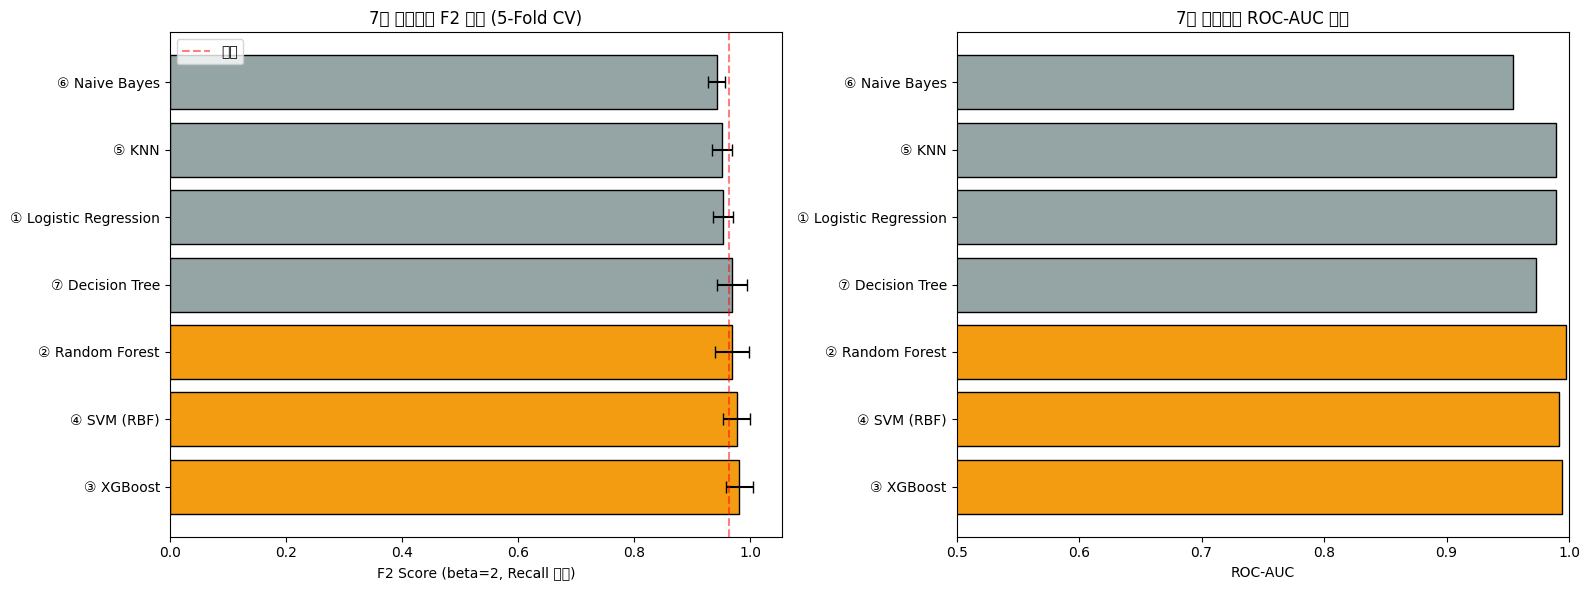

주황색 = 상위 3개 (심층 비교 대상)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top3_names = set(df_cv.index[:3])
colors_bar = ['#f39c12' if n in top3_names else '#95a5a6' for n in df_cv.index]

axes[0].barh(df_cv.index, df_cv['F2'], color=colors_bar, edgecolor='black',
             xerr=df_cv['F2_std'], capsize=4)
axes[0].set_xlabel('F2 Score (beta=2, Recall 가중)')
axes[0].set_title('7개 알고리즘 F2 비교 (5-Fold CV)')
axes[0].axvline(df_cv['F2'].mean(), color='red', linestyle='--', alpha=0.5, label='평균')
axes[0].legend()

axes[1].barh(df_cv.index, df_cv['ROC_AUC'], color=colors_bar, edgecolor='black')
axes[1].set_xlabel('ROC-AUC')
axes[1].set_title('7개 알고리즘 ROC-AUC 비교')
axes[1].set_xlim(0.5, 1.0)

plt.tight_layout()
plt.savefig('../docs/cv_7algo_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('주황색 = 상위 3개 (심층 비교 대상)')

---
## 4. 선택 3개 알고리즘 심층 학습

DLP 평가 기준: **Recall >= 0.97** 보장 하에서 Precision 최대화

In [10]:
# 4.1 Logistic Regression
lr_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', solver='lbfgs', random_state=42))
])
lr_pipe.fit(X_train, y_train)
lr_proba = lr_pipe.predict_proba(X_test)[:, 1]
lr_pred  = lr_pipe.predict(X_test)

print('=== Logistic Regression ===')
print(classification_report(y_test, lr_pred, target_names=['FP(0)', 'TP(1)']))

=== Logistic Regression ===
              precision    recall  f1-score   support

       FP(0)       0.95      0.83      0.89        47
       TP(1)       0.85      0.96      0.90        47

    accuracy                           0.89        94
   macro avg       0.90      0.89      0.89        94
weighted avg       0.90      0.89      0.89        94



In [11]:
# 4.2 Random Forest
rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                   class_weight='balanced', random_state=42, n_jobs=-1))
])
rf_pipe.fit(X_train, y_train)
rf_proba = rf_pipe.predict_proba(X_test)[:, 1]
rf_pred  = rf_pipe.predict(X_test)

print('=== Random Forest ===')
print(classification_report(y_test, rf_pred, target_names=['FP(0)', 'TP(1)']))

=== Random Forest ===
              precision    recall  f1-score   support

       FP(0)       0.98      1.00      0.99        47
       TP(1)       1.00      0.98      0.99        47

    accuracy                           0.99        94
   macro avg       0.99      0.99      0.99        94
weighted avg       0.99      0.99      0.99        94



In [12]:
# 4.3 XGBoost
xgb_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                               subsample=0.8, colsample_bytree=0.8,
                               eval_metric='logloss', random_state=42, verbosity=0))
])
xgb_pipe.fit(X_train, y_train)
xgb_proba = xgb_pipe.predict_proba(X_test)[:, 1]
xgb_pred  = xgb_pipe.predict(X_test)

print('=== XGBoost ===')
print(classification_report(y_test, xgb_pred, target_names=['FP(0)', 'TP(1)']))

=== XGBoost ===
              precision    recall  f1-score   support

       FP(0)       1.00      1.00      1.00        47
       TP(1)       1.00      1.00      1.00        47

    accuracy                           1.00        94
   macro avg       1.00      1.00      1.00        94
weighted avg       1.00      1.00      1.00        94



---
## 5. 평가 비교 — PR Curve / ROC / Confusion Matrix

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


...

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


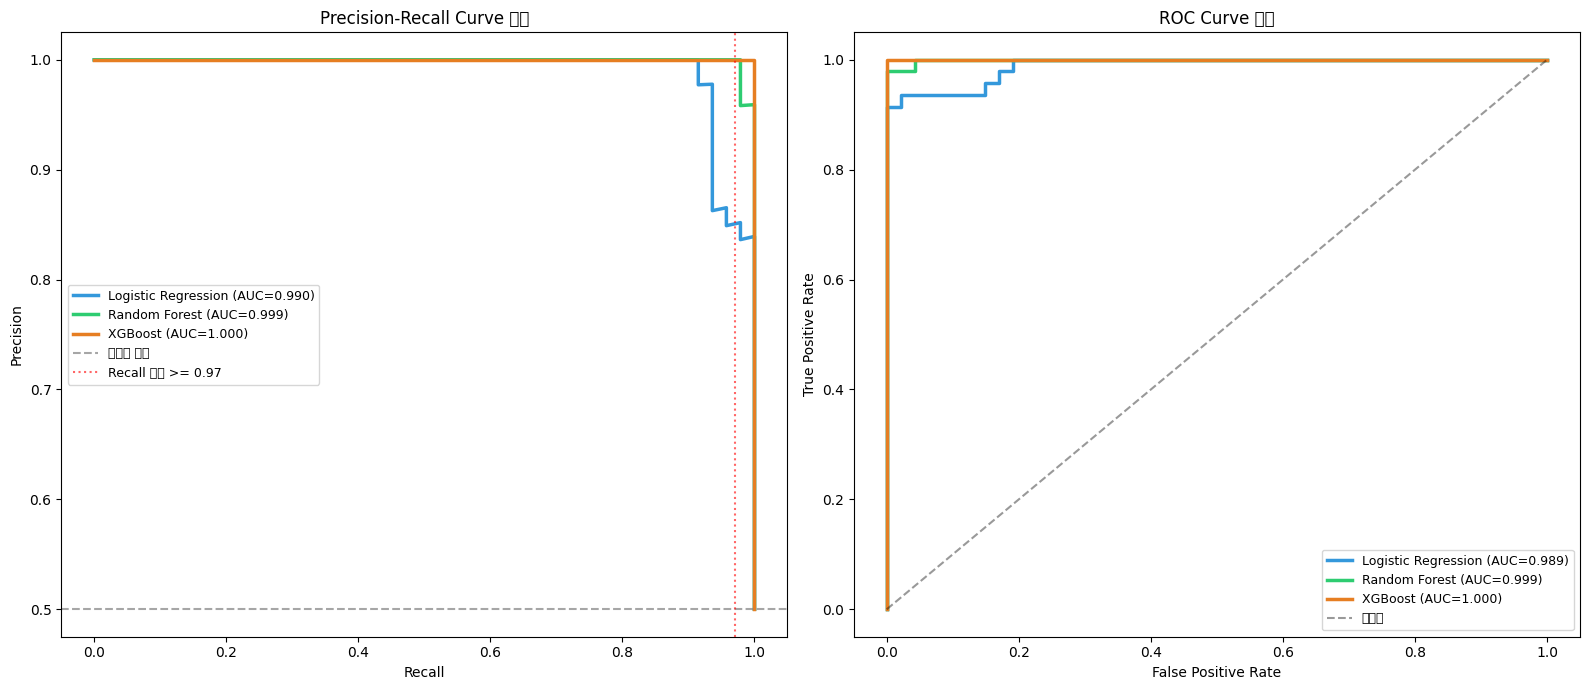

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

models_info = [
    ('Logistic Regression', lr_proba,  '#3498db'),
    ('Random Forest',       rf_proba,  '#2ecc71'),
    ('XGBoost',             xgb_proba, '#e67e22'),
]

for name, proba, color in models_info:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    pr_auc = auc(rec, prec)
    axes[0].plot(rec, prec, color=color, lw=2.5, label=f'{name} (AUC={pr_auc:.3f})')

axes[0].axhline(y_test.mean(), color='gray', linestyle='--', alpha=0.7, label='무작위 기준')
axes[0].axvline(0.97, color='red', linestyle=':', alpha=0.6, label='Recall 목표 >= 0.97')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve 비교')
axes[0].legend(fontsize=9)

for name, proba, color in models_info:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[1].plot(fpr, tpr, color=color, lw=2.5, label=f'{name} (AUC={auc(fpr, tpr):.3f})')

axes[1].plot([0,1],[0,1], 'k--', alpha=0.4, label='무작위')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve 비교')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../docs/pr_roc_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


...

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


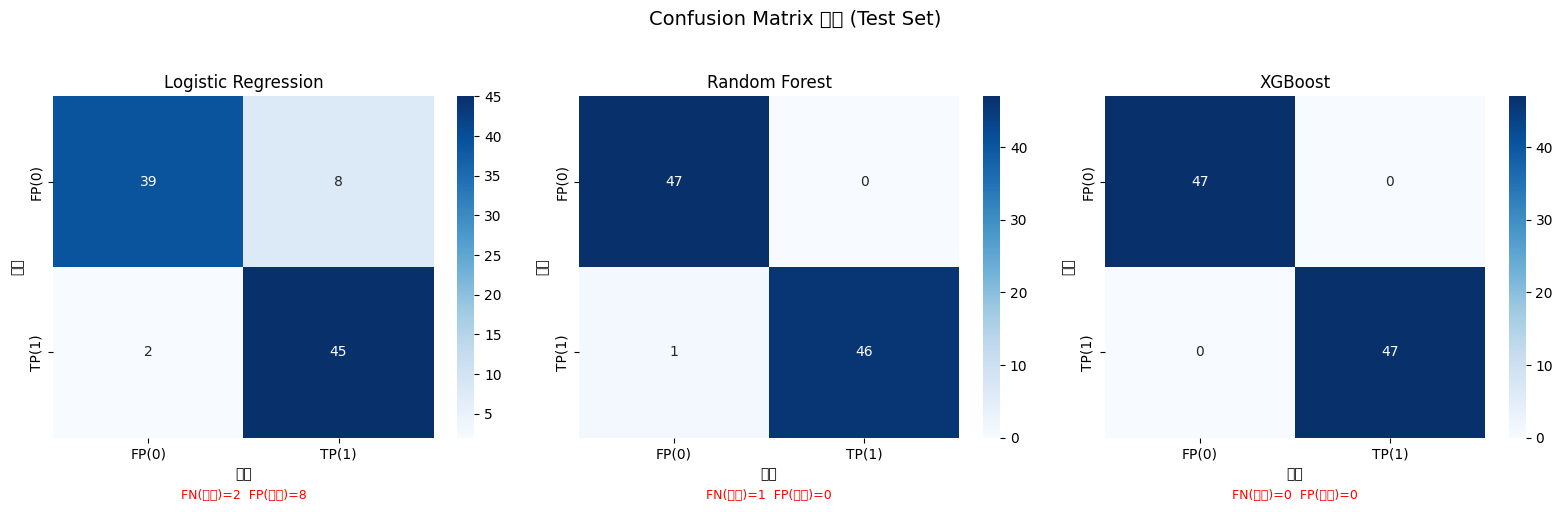

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, pred) in zip(axes, [
    ('Logistic Regression', lr_pred),
    ('Random Forest',       rf_pred),
    ('XGBoost',             xgb_pred),
]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['FP(0)', 'TP(1)'], yticklabels=['FP(0)', 'TP(1)'])
    ax.set_title(name)
    ax.set_xlabel('예측')
    ax.set_ylabel('실제')
    tn, fp, fn, tp = cm.ravel()
    ax.text(0.5, -0.18, f'FN(미탐)={fn}  FP(과탐)={fp}',
            transform=ax.transAxes, ha='center', fontsize=9, color='red')

plt.suptitle('Confusion Matrix 비교 (Test Set)', fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig('../docs/confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

In [15]:
def eval_metrics(y_true, y_pred, y_proba, name):
    prec_arr, rec_arr, _ = precision_recall_curve(y_true, y_proba)
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'Model':      name,
        'Precision':  round(precision_score(y_true, y_pred, pos_label=1, zero_division=0), 4),
        'Recall':     round(recall_score(y_true, y_pred, pos_label=1), 4),
        'F1':         round(f1_score(y_true, y_pred, pos_label=1), 4),
        'F2(b=2)':    round(fbeta_score(y_true, y_pred, beta=2, pos_label=1, zero_division=0), 4),
        'ROC-AUC':    round(roc_auc_score(y_true, y_proba), 4),
        'PR-AUC':     round(auc(rec_arr, prec_arr), 4),
        'FN(미탐)':   int(fn),
        'FP(과탐)':   int(fp),
    }

results = pd.DataFrame([
    eval_metrics(y_test, lr_pred,  lr_proba,  'Logistic Regression'),
    eval_metrics(y_test, rf_pred,  rf_proba,  'Random Forest'),
    eval_metrics(y_test, xgb_pred, xgb_proba, 'XGBoost'),
]).set_index('Model')

print('=== 3개 알고리즘 Test Set 종합 성능 비교 ===')
print(results.to_string())
results

=== 3개 알고리즘 Test Set 종합 성능 비교 ===
                     Precision  Recall      F1  F2(b=2)  ROC-AUC  PR-AUC  FN(미탐)  FP(과탐)
Model                                                                                   
Logistic Regression     0.8491  0.9574  0.9000   0.9336   0.9887  0.9900       2       8
Random Forest           1.0000  0.9787  0.9892   0.9829   0.9991  0.9991       1       0
XGBoost                 1.0000  1.0000  1.0000   1.0000   1.0000  1.0000       0       0


,Precision,Recall,F1,F2(b=2),ROC-AUC,PR-AUC,FN(미탐),FP(과탐)
Model,,,,,,,,
Logistic Regression,0.8491,0.9574,0.9000,0.9336,0.9887,0.9900,2,8
Random Forest,1.0000,0.9787,0.9892,0.9829,0.9991,0.9991,1,0
XGBoost,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0,0


---
## 6. Feature Importance 분석

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


...

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


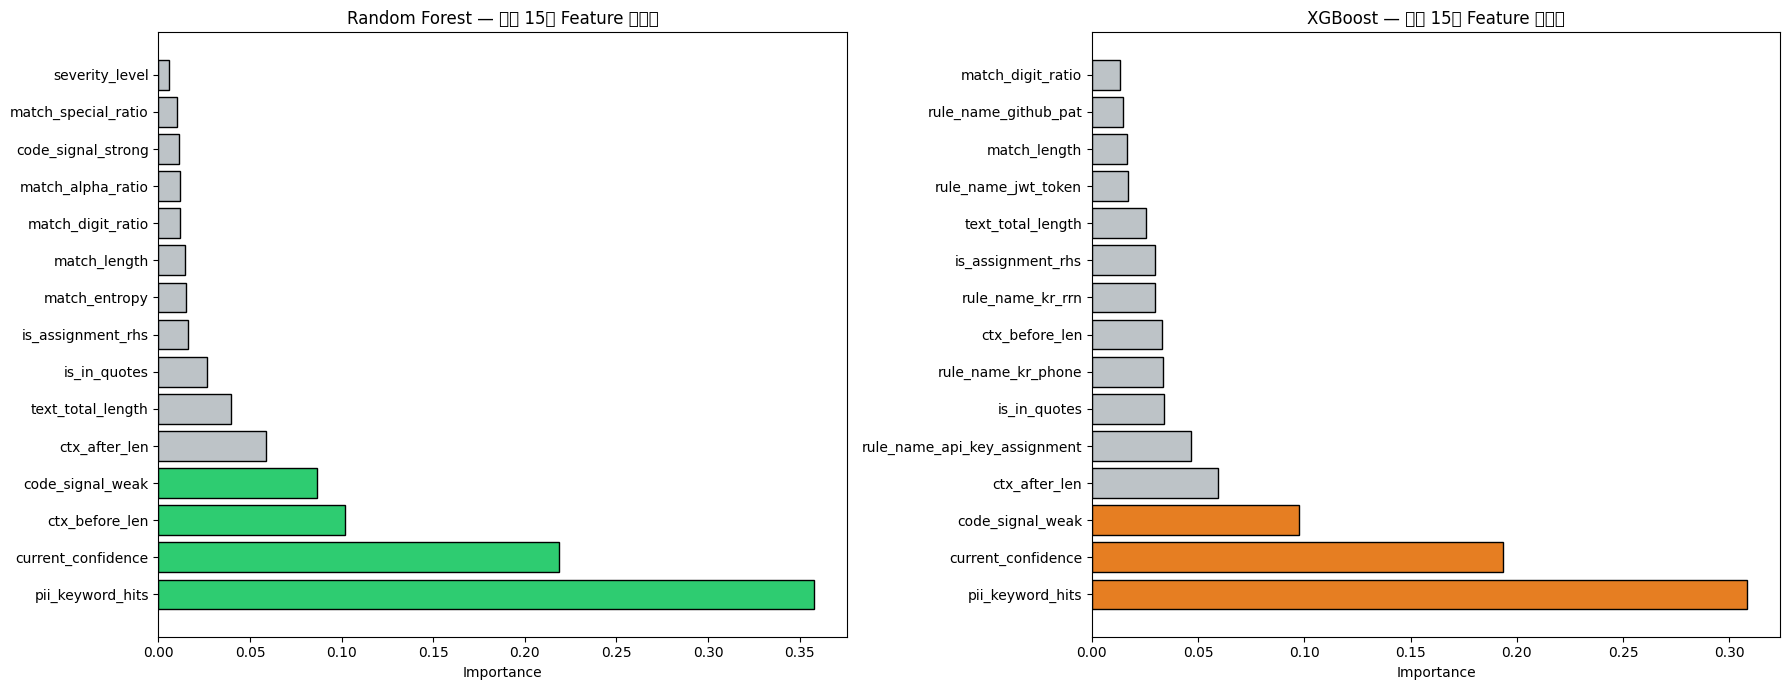

In [16]:
prep_fitted = rf_pipe.named_steps['prep']
cat_feat_names = list(prep_fitted.named_transformers_['cat'].get_feature_names_out(cat_cols))
all_feat_names = num_cols + cat_feat_names

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (name, pipe, color) in zip(axes, [
    ('Random Forest', rf_pipe,  '#2ecc71'),
    ('XGBoost',       xgb_pipe, '#e67e22'),
]):
    imps = pipe.named_steps['clf'].feature_importances_
    fi = pd.DataFrame({'feature': all_feat_names, 'importance': imps})
    fi = fi.sort_values('importance', ascending=False).head(15)
    bar_colors = [color if fi.iloc[i]['importance'] > fi['importance'].mean() else '#bdc3c7'
                  for i in range(len(fi))]
    ax.barh(fi['feature'], fi['importance'], color=bar_colors, edgecolor='black')
    ax.set_title(f'{name} — 상위 15개 Feature 중요도')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('../docs/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 7. 임계값 분석 — DLP 보안 최적 임계값

> **DLP 원칙**: 미탐(FN) = 민감정보 유출 → Recall 최우선  
> **목표**: Recall >= 0.97 조건에서 Precision이 가장 높은 임계값 탐색

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


...

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


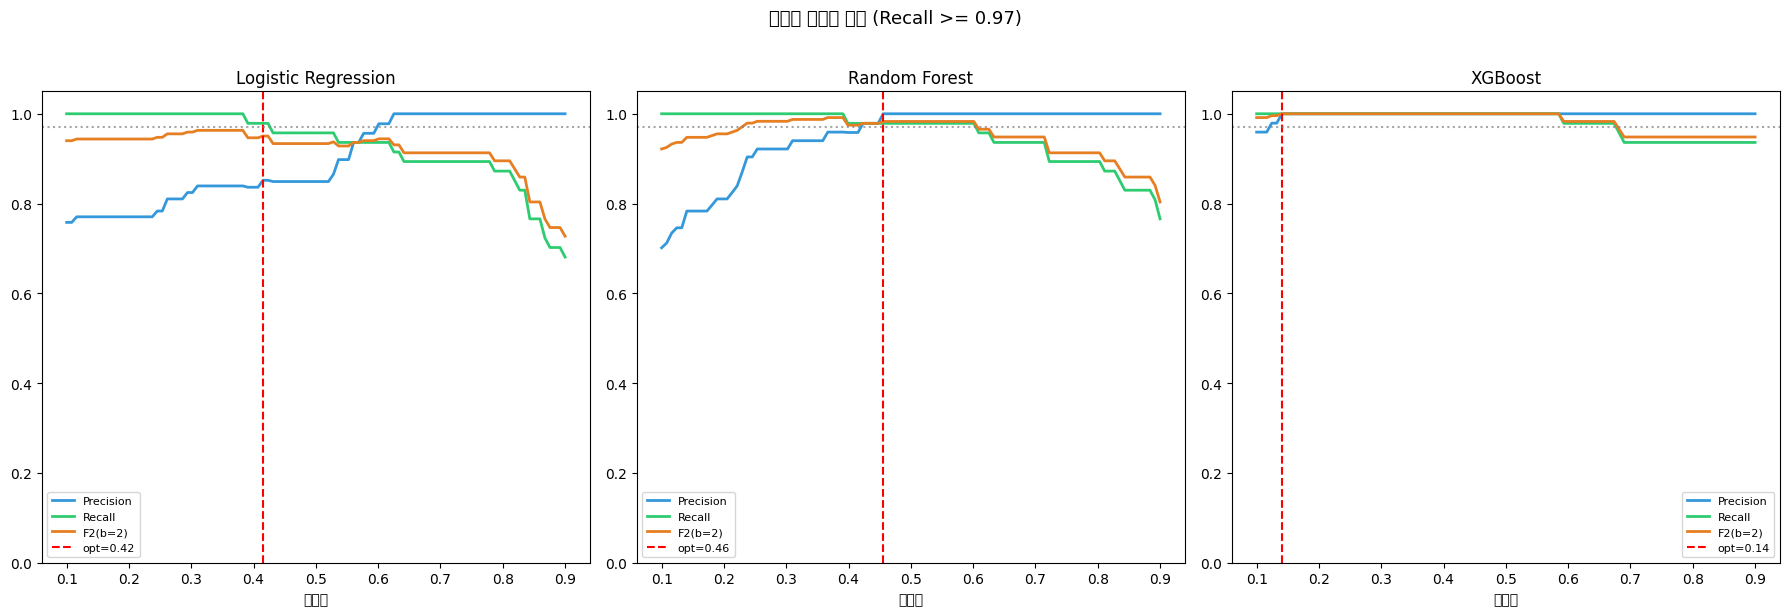


=== DLP 최적 임계값 (Recall >= 0.97 조건) ===
  Logistic Regression: 0.42
  Random Forest: 0.46
  XGBoost: 0.14


In [17]:
RECALL_TARGET = 0.97
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
optimal_thresholds = {}

for ax, (name, proba) in zip(axes, [
    ('Logistic Regression', lr_proba),
    ('Random Forest',       rf_proba),
    ('XGBoost',             xgb_proba),
]):
    thresholds = np.linspace(0.1, 0.9, 100)
    precs, recs, f2s = [], [], []

    for t in thresholds:
        pred_t = (proba >= t).astype(int)
        if pred_t.sum() == 0:
            precs.append(0); recs.append(0); f2s.append(0)
            continue
        precs.append(precision_score(y_test, pred_t, pos_label=1, zero_division=0))
        recs.append(recall_score(y_test, pred_t, pos_label=1))
        f2s.append(fbeta_score(y_test, pred_t, beta=2, pos_label=1, zero_division=0))

    valid = [(t, p) for t, p, r in zip(thresholds, precs, recs) if r >= RECALL_TARGET]
    opt_t = max(valid, key=lambda x: x[1])[0] if valid else 0.5
    optimal_thresholds[name] = round(float(opt_t), 2)

    ax.plot(thresholds, precs, label='Precision', color='#3498db', lw=2)
    ax.plot(thresholds, recs,  label='Recall',    color='#2ecc71', lw=2)
    ax.plot(thresholds, f2s,   label='F2(b=2)',   color='#e67e22', lw=2)
    ax.axvline(opt_t, color='red', linestyle='--', lw=1.5, label=f'opt={opt_t:.2f}')
    ax.axhline(RECALL_TARGET, color='gray', linestyle=':', alpha=0.7)
    ax.set_title(name)
    ax.set_xlabel('임계값')
    ax.set_ylim([0, 1.05])
    ax.legend(fontsize=8)

plt.suptitle(f'임계값 민감도 분석 (Recall >= {RECALL_TARGET})', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../docs/threshold_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n=== DLP 최적 임계값 (Recall >= 0.97 조건) ===')
for k, v in optimal_thresholds.items():
    print(f'  {k}: {v}')

---
## 8. 최적 모델 선정 및 DLP 파이프라인 통합 시뮬레이션

In [18]:
final_rows = []
for name, proba, thresh in [
    ('Logistic Regression', lr_proba,  optimal_thresholds.get('Logistic Regression', 0.5)),
    ('Random Forest',       rf_proba,  optimal_thresholds.get('Random Forest', 0.5)),
    ('XGBoost',             xgb_proba, optimal_thresholds.get('XGBoost', 0.5)),
]:
    pred = (proba >= thresh).astype(int)
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    final_rows.append({
        '모델': name, '임계값': thresh,
        'Precision': round(precision_score(y_test, pred, pos_label=1, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, pred, pos_label=1), 4),
        'F2(b=2)':   round(fbeta_score(y_test, pred, beta=2, pos_label=1, zero_division=0), 4),
        'TP': int(tp), 'FP(과탐)': int(fp), 'FN(미탐)': int(fn),
    })

final_df = pd.DataFrame(final_rows).set_index('모델')
print('=== 최적 임계값 적용 후 최종 비교 ===')
print(final_df.to_string())

=== 최적 임계값 적용 후 최종 비교 ===
                      임계값  Precision  Recall  F2(b=2)  TP  FP(과탐)  FN(미탐)
모델                                                                       
Logistic Regression  0.42     0.8519  0.9787   0.9504  46       8       1
Random Forest        0.46     1.0000  0.9787   0.9829  46       0       1
XGBoost              0.14     1.0000  1.0000   1.0000  47       0       0


In [19]:
best_name = final_df['F2(b=2)'].idxmax()
best_threshold = optimal_thresholds.get(best_name, 0.5)
best_pipe_map = {'Logistic Regression': lr_pipe, 'Random Forest': rf_pipe, 'XGBoost': xgb_pipe}
best_pipe = best_pipe_map[best_name]

print(f'★ 최종 선정: {best_name}  (F2={final_df.loc[best_name, "F2(b=2)"]:.4f}, threshold={best_threshold})')

joblib.dump({'pipeline': best_pipe, 'threshold': best_threshold, 'model': best_name},
            '../tests/fp_filter_best_model.pkl')
print('모델 저장: tests/fp_filter_best_model.pkl')

★ 최종 선정: XGBoost  (F2=1.0000, threshold=0.14)
모델 저장: tests/fp_filter_best_model.pkl


In [20]:
# Before/After 시뮬레이션
best_proba = best_pipe_map[best_name].predict_proba(X_test)[:, 1]
y_after = (best_proba >= best_threshold).astype(int)

total_fp_before = int((y_test == 0).sum())
total_tp        = int((y_test == 1).sum())
after_fp  = int(((y_test == 0) & (y_after == 1)).sum())
after_fn  = int(((y_test == 1) & (y_after == 0)).sum())

print('=' * 55)
print('DLP 파이프라인 통합 효과')
print('=' * 55)
print(f'[기존] 모든 Regex 탐지를 그대로 통과')
print(f'  과탐(FP): {total_fp_before}건 모두 경보 발생')
print(f'  미탐(FN): 0건')
print()
print(f'[ML 필터 적용 후 — {best_name}]')
print(f'  과탐 억제: {total_fp_before - after_fp}/{total_fp_before}건 ({(total_fp_before-after_fp)/total_fp_before*100:.1f}%)')
print(f'  미탐 발생: {after_fn}/{total_tp}건  ({after_fn/total_tp*100:.1f}%)')
print(f'  TP 보존율: {(1-after_fn/total_tp)*100:.1f}%')

DLP 파이프라인 통합 효과
[기존] 모든 Regex 탐지를 그대로 통과
  과탐(FP): 47건 모두 경보 발생
  미탐(FN): 0건

[ML 필터 적용 후 — XGBoost]
  과탐 억제: 47/47건 (100.0%)
  미탐 발생: 0/47건  (0.0%)
  TP 보존율: 100.0%


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


...

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


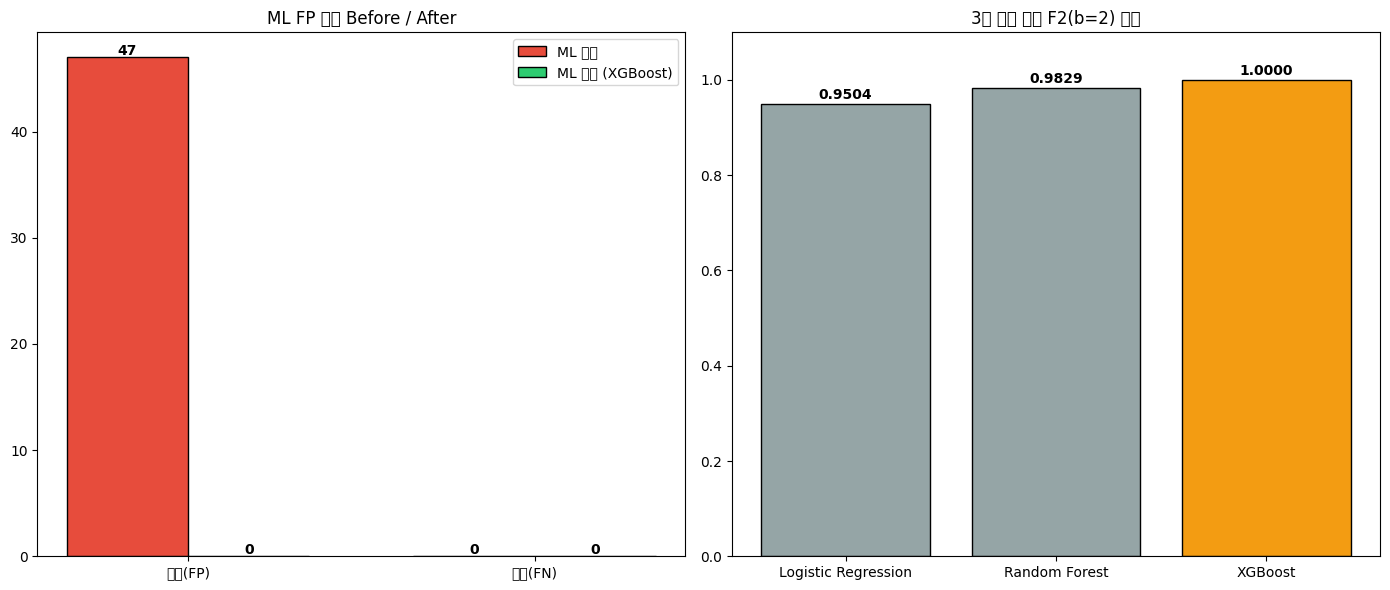


★ 최종 선정: XGBoost  임계값=0.14


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Before/After
x = np.arange(2)
w = 0.35
before_vals = [total_fp_before, 0]
after_vals  = [after_fp, after_fn]
axes[0].bar(x - w/2, before_vals, w, label='ML 없음', color='#e74c3c', edgecolor='black')
axes[0].bar(x + w/2, after_vals,  w, label=f'ML 적용 ({best_name})', color='#2ecc71', edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['과탐(FP)', '미탐(FN)'])
axes[0].set_title('ML FP 필터 Before / After')
axes[0].legend()
for i, (b, a) in enumerate(zip(before_vals, after_vals)):
    axes[0].text(i - w/2, b + 0.2, str(b), ha='center', fontweight='bold')
    axes[0].text(i + w/2, a + 0.2, str(a), ha='center', fontweight='bold')

# 3모델 F2 최종 비교
f2_vals = final_df['F2(b=2)'].tolist()
bar_c   = ['#f39c12' if n == best_name else '#95a5a6' for n in final_df.index]
axes[1].bar(final_df.index, f2_vals, color=bar_c, edgecolor='black')
axes[1].set_title('3개 모델 최종 F2(b=2) 비교')
axes[1].set_ylim([0, 1.1])
for i, v in enumerate(f2_vals):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/final_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'\n★ 최종 선정: {best_name}  임계값={best_threshold}')

---
## 9. 결론

### 알고리즘 비교 요약

| 알고리즘 | 특징 | 장점 | 단점 |
|---|---|---|---|
| Logistic Regression | 선형 분류기 | 빠른 학습, 해석 쉬움 | 비선형 경계 불가 |
| Random Forest | 배깅 앙상블 | 강건, feature importance | 추론 상대적으로 느림 |
| XGBoost | 부스팅 앙상블 | tabular 최고 성능, 빠른 추론 | 하이퍼파라미터 많음 |

### DLP 도메인 특화 설계 포인트
1. **F2-Score (beta=2)** 사용 → Recall에 2배 가중치 (FN이 FP보다 치명적)
2. **Recall >= 0.97 제약** 하에 임계값 최적화
3. 기존 규칙 기반 파이프라인에 **추가 게이트**로 통합 (안전 fallback 유지)

### 창의적 기여
> **하이브리드 DLP**: 규칙(Regex)으로 잡고 ML로 거른다.  
> 실제 산업(금융, 의료 데이터 보호)에서 적용 가능한 보안 ML 패턴.